# Transformer -> GPT 변경이 필요한 부분

GPT는 트랜스포머의 구조를 계승합니다.

비지도 사전 학습(Unsupervised Pre-training)과 

범용적인 활용할 수 있도록 변경이 필요합니다.

### [아키텍처 상의 주요 변경 사항]

* **인코더(Encoder) 제거 및 디코더(Decoder) 단독 사용**
    * **Transformer**: 입력 문장을 해석하는 인코더와 문장을 생성하는 디코더가 쌍을 이루는 구조입니다.
    * **GPT**: 인코더를 완전히 제거하고, 다층 트랜스포머 디코더(Multi-layer Transformer Decoder)만을 사용합니다. 이는 라벨 없는 텍스트로부터 언어의 문맥을 스스로 학습하는 데 최적화된 구조이기 때문입니다.
* **어텐션(Attention) 구조 단순화 (Cross-Attention 삭제)**
    * **Transformer**: 디코더 내부에는 자기 자신을 보는 'Self-Attention'과 인코더의 정보를 가져오는 'Encoder-Decoder Attention(Cross-Attention)'이 공존합니다.
    * **GPT:** 인코더가 없으므로 인코더와 상호작용하는 두 번째 어텐션 층을 삭제합니다. 오직 이전 토큰들만을 참고하여 다음 토큰을 예측하는 Masked Self-Attention만 남깁니다.
* **포지셔널 임베딩(Positional Embedding)의 변화**
    * **Transformer:** 사인/코사인 함수를 기반으로 고정된 'sinusoidal Positional Encoding'을 사용합니다.
    * **GPT:** 위치 정보 또한 모델이 학습을 통해 최적화할 수 있도록 학습 가능한 포지셔널 임베딩(Learned Positional Embedding)으로 변경되었습니다.
* **작업별 입력 변환 방식 (Task-specific Input Transformation)**
    * **Transformer:** 특정 작업(질문 응답, 추론 등)을 수행할 때 모델 구조 자체를 변경해야 하는 경우가 많습니다.
    * **GPT:** 모델 구조 변경을 최소화하기 위해 순회 방식(Traversal-style approach)을 사용합니다. 즉, 질문이나 답변 등 구조화된 입력을 구분자(Delimiter)를 포함한 하나의 연속적인 토큰 시퀀스로 변환하여 모델이 처리할 수 있게 합니다.

# 환경 및 데이터 준비

## 라이브러리

### 라이브러리 설치

In [ ]:
# !apt-get update
# !apt-get install g++ openjdk-8-jdk -y
# !pip install konlpy mecab-python3
# !bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)
# !pip install gensim

In [ ]:
# !python3 -m pip install --upgrade pip
# !python3 -m pip install konlpy # Python 3.x
# !bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) # MeCab 설치하기
# !pip install sentencepiece nltk

### 라이브러리 import

In [1]:
import numpy as np
import pandas as pd
import torch
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
from konlpy.tag import Mecab
import gensim

import re
import os
import random
import math

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(torch.__version__)

2.5.1+cu121


## 데이터 파일 로드

In [2]:
# 데이터 로드 (파일 경로에 맞게 수정해주세요)
data_path = 'ChatbotData.csv'
chatbot_data = pd.read_csv(data_path)

questions = chatbot_data['Q'].tolist()
answers = chatbot_data['A'].tolist()

print(f"전체 질문 수: {len(questions)}")
print(f"전체 답변 수: {len(answers)}")

전체 질문 수: 11823
전체 답변 수: 11823


## 전처리 함수
1. 소문자 변환
2. 영문자, 한글, 숫자, 주요 특수문자(.,?!) 제외한 문자 제거

In [3]:
def preprocess_sentence(sentence):
    sentence = sentence.lower() # 1. 영문자 소문자 변환
    sentence = re.sub(r'[^a-zA-Z가-힣0-9.,?!]', ' ', sentence) # 2. 영문자, 한글, 숫자, 주요 특수문자(.,?!) 제외한 문자 제거
    return sentence

## 토큰화 및 말뭉치 구축
1. KoNLPy의 Mecab을 활용하여 토큰화를 진행합니다.
2. `preprocess_sentence()`로 정제 후 토큰화를 수행합니다.
3. 소스(질문)와 타겟(답변)의 토큰 길이가 40 이하인 문장만 남깁니다.
4. 중복되는 문장은 소스와 타겟을 독립적으로 검사하여 제거하되, 쌍이 흐트러지지 않도록 `build_corpus` 함수 내에서 처리합니다.

In [4]:
mecab = Mecab()

def build_corpus(src_data, tgt_data):
    que_corpus = []
    ans_corpus = []
    
    # 중복 검사를 위한 set
    seen_src = set()
    seen_tgt = set()
    
    for src, tgt in tqdm(zip(src_data, tgt_data), total=len(src_data)):
        # 1. 정제 (전처리)
        clean_src = preprocess_sentence(src)
        clean_tgt = preprocess_sentence(tgt)
        
        # 2. 토큰화
        tok_src = mecab.morphs(clean_src)
        tok_tgt = mecab.morphs(clean_tgt)
        
        # 3. 길이 조건 검사 (예: 20 이하)
        if len(tok_src) == 0 or len(tok_tgt) == 0: 
            continue
        if len(tok_src) > 20 or len(tok_tgt) > 20: 
            continue
            
        # 4. 중복 검사 (소스와 타겟 독립적 검사)
        # 리스트 형태인 토큰을 문자열로 합쳐서 중복 여부 확인
        src_str = " ".join(tok_src)
        tgt_str = " ".join(tok_tgt)
        
        if src_str in seen_src or tgt_str in seen_tgt:
            continue # 둘 중 하나라도 중복이면 해당 쌍은 제외
            
        # 중복이 아니면 set에 추가하고 corpus에 저장
        seen_src.add(src_str)
        seen_tgt.add(tgt_str)
        
        que_corpus.append(tok_src)
        ans_corpus.append(tok_tgt)
        
    return que_corpus, ans_corpus

print("슝=3")

슝=3


- corpus 구축 실행 및 확인

In [5]:
# [cite_start]함수를 실행하여 말뭉치를 구축합니다. [cite: 59, 62]
que_corpus, ans_corpus = build_corpus(questions, answers)

print(f"구축된 질문 말뭉치 크기: {len(que_corpus)}")
print(f"구축된 답변 말뭉치 크기: {len(ans_corpus)}")

print("\n[토큰화 확인]")
print("Q:", que_corpus[0])
print("A:", ans_corpus[0])

  0%|          | 0/11823 [00:00<?, ?it/s]

구축된 질문 말뭉치 크기: 7569
구축된 답변 말뭉치 크기: 7569

[토큰화 확인]
Q: ['12', '시', '땡', '!']
A: ['하루', '가', '또', '가', '네요', '.']


## 데이터 증강
- 한국어 Word2Vec 모델(ko.bin)을 활용하여 Lexical Substitution 구현
- 원본(Q-A), 증강(Aug_Q-A), 증강(Q-Aug_A) 형태로 데이터를 약 3배로 증강

#### gensim 에러

KeyedVectors.load_word2vec_format(..., binary=True) 코드가 작동했다는 것은, 

해당 파일이 파이썬의 pickle 객체로 저장된 것이 아니라 

C 언어 기반의 오리지널 Word2Vec 바이너리 포맷으로 저장된 파일이라는 뜻입니다.

In [6]:
from gensim.models import KeyedVectors
wv = KeyedVectors.load_word2vec_format('ko_converted.bin', binary=True)

print("로드 완료!")
print(len(wv))                     # 단어 수 확인
print(wv['인공지능'].shape)        # 벡터 차원 (보통 200)
print(wv.most_similar('서울', topn=5))

로드 완료!
30185
(200,)
[('서울시', 0.6911441087722778), ('서울특별시', 0.6897672414779663), ('성남', 0.6770074963569641), ('부천', 0.6612347364425659), ('인천', 0.6545476913452148)]


#### Lexical Substitution 함수 정의

In [7]:
import random
import math

# 문장 길이에 비례하여 교체할 단어 수(n_replace)를 동적으로 결정
def get_n_replace(tokens):
    # 단어 수의 약 15% 정도를 교체/삽입하되, 최소 1개, 최대 3개로 제한
    return max(1, min(3, int(len(tokens) * 0.15)))

# 1. 단어 교체 (Lexical Substitution) - topn=3으로 확장 및 n_replace 적용
def lexical_sub(tokens, wv, topn=3):
    valid_tokens = [tok for tok in tokens if tok in wv]
    if not valid_tokens:
        return None
        
    n_replace = get_n_replace(tokens)
    # 교체할 단어를 n_replace개만큼 무작위로 선택 (중복 허용 X)
    n_replace = min(n_replace, len(valid_tokens))
    selected_toks = random.sample(valid_tokens, n_replace)
    
    new_tokens = tokens.copy()
    for selected_tok in selected_toks:
        try:
            # topn 개수만큼 유사한 단어를 추출하여 그 중 하나를 무작위로 선택
            similars = wv.most_similar(selected_tok, topn=topn)
            similar_word = random.choice(similars)[0]
            
            # 선택된 단어를 새로운 단어로 교체 (첫 번째로 일치하는 것만 교체)
            idx = new_tokens.index(selected_tok)
            new_tokens[idx] = similar_word
        except:
            continue
            
    if new_tokens == tokens:
        return None
        
    return new_tokens

# 2. Random Swap (RS) - 두 단어의 위치를 바꿈
def random_swap(words):
    if len(words) < 2:
        return None
    new_words = words.copy()
    idx1, idx2 = random.sample(range(len(new_words)), 2)
    new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return new_words

# 3. Random Deletion (RD) - 확률 p로 단어 삭제
def random_deletion(words, p=0.1):
    if len(words) == 1:
        return None
        
    new_words = []
    for word in words:
        if random.random() > p:
            new_words.append(word)
            
    # 모든 단어가 삭제되면 원래 단어 중 하나를 무작위로 반환
    if len(new_words) == 0:
        return [random.choice(words)]
        
    if new_words == words:
        return None
    return new_words

# 4. Random Insertion (RI) - 임의의 단어와 유사한 단어를 무작위 위치에 삽입
def random_insertion(words, wv):
    valid_tokens = [tok for tok in words if tok in wv]
    if not valid_tokens:
        return None
        
    n_insert = get_n_replace(words)
    new_words = words.copy()
    
    for _ in range(n_insert):
        random_word = random.choice(valid_tokens)
        try:
            similar_word = wv.most_similar(random_word, topn=1)[0][0]
            random_idx = random.randint(0, len(new_words))
            new_words.insert(random_idx, similar_word)
        except:
            continue
            
    if len(new_words) == len(words):
        return None
        
    return new_words

# --- [추가할 코드] ---
# 단어 사전을 강제로 팽창시키기 위한 특수 주입 함수
def force_vocab_expansion(wv, target_size=20000):
    expansion_tokens = []
    # wv.index_to_key 는 Word2Vec이 아는 모든 단어 리스트야
    # 앞쪽의 가장 많이 쓰이는 1만~1만5천 개 단어를 무작위로 뽑아서 리스트화해
    vocab_candidates = wv.index_to_key[:target_size]
    
    # 너무 많이 넣으면 메모리가 터질 수 있으니 1만 개 정도만 잘라서 반환
    selected_expansion = random.sample(vocab_candidates, min(len(vocab_candidates), 12000))
    return selected_expansion


print("데이터 증강 기법(Lexical Sub, RS, RD, RI) 및 길이 비례 n_replace 정의 완료!")


데이터 증강 기법(Lexical Sub, RS, RD, RI) 및 길이 비례 n_replace 정의 완료!


#### 증강 실행

In [8]:
from tqdm.notebook import tqdm

aug_que_corpus = []
aug_ans_corpus = []

for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus)):
    # 0. 원본 데이터 무조건 추가
    aug_que_corpus.append(q)
    aug_ans_corpus.append(a)
    
    # --- Lexical Substitution (다양성 증가를 위해 두 번 시도) ---
    q_sub1 = lexical_sub(q, wv, topn=3)
    a_sub1 = lexical_sub(a, wv, topn=3)
    
    q_sub2 = lexical_sub(q, wv, topn=3)
    a_sub2 = lexical_sub(a, wv, topn=3)
    
    # 1. 질문만 교체
    if q_sub1:
        aug_que_corpus.append(q_sub1)
        aug_ans_corpus.append(a)
    # 2. 답변만 교체
    if a_sub1:
        aug_que_corpus.append(q)
        aug_ans_corpus.append(a_sub1)
    # 3. 둘 다 교체
    if q_sub2 and a_sub2:
        aug_que_corpus.append(q_sub2)
        aug_ans_corpus.append(a_sub2)
        
    # --- EDA 기법: Random Swap (질문에만 노이즈 적용) ---
    q_swap = random_swap(q)
    if q_swap:
        aug_que_corpus.append(q_swap)
        aug_ans_corpus.append(a) # 답변은 원본 유지
        
    # --- EDA 기법: Random Deletion (질문에만 노이즈 적용, p=0.1) ---
    q_delete = random_deletion(q, p=0.1)
    if q_delete:
        aug_que_corpus.append(q_delete)
        aug_ans_corpus.append(a)
        
    # --- EDA 기법: Random Insertion (질문에만 추가) ---
    q_insert = random_insertion(q, wv)
    if q_insert:
        aug_que_corpus.append(q_insert)
        aug_ans_corpus.append(a)

# 5. OOTV Injection: 단어 사전 규모를 2만 개로 강제 팽창시키기 위한 더미(Dummy) 데이터 삽입
expansion_words = force_vocab_expansion(wv, target_size=20000)
# 이 단어들을 100개씩 묶어서 가짜 질문(Q)으로 만들고, 답변(A)은 점(.) 하나로 때운다.
# 이렇게 하면 나중에 CustomTokenizer가 이 단어들을 전부 새 단어로 인식해서 사전에 등록해!
chunk_size = 100
for i in range(0, len(expansion_words), chunk_size):
    dummy_q = expansion_words[i:i+chunk_size]
    dummy_a = ['.'] 
    aug_que_corpus.append(dummy_q)
    aug_ans_corpus.append(dummy_a)
    
print(f"원본 말뭉치 개수 저장: {len(que_corpus)}")
print(f"증강 완료 후 전체 데이터 개수: {len(aug_que_corpus)}")


  0%|          | 0/7569 [00:00<?, ?it/s]

원본 말뭉치 개수 저장: 7569
증강 완료 후 전체 데이터 개수: 49123


## 특수 토큰 추가 및 단어 사전 구축
- 타겟 데이터(답변) 양끝에 `<start>`와 `<end>` 토큰을 추가합니다.
- SentencePiece와 동일한 메서드를 가진 CustomTokenizer를 만들어 트랜스포머 모델과의 호환성을 유지합니다.

토큰 추가 및 Custom Tokenizer

In [9]:
print(f"원본 질문 말뭉치 크기: {len(que_corpus)}")
print(f"증강 후 질문 말뭉치 크기: {len(aug_que_corpus)}")
print(f"원본 답변 말뭉치 크기: {len(ans_corpus)}")
print(f"증강 후 답변 말뭉치 크기: {len(aug_ans_corpus)}")

# 확인: 증강된 데이터가 원본과 어떻게 다른지 일부 출력
for i in range(5):
    print(f"--- 샘플 {i} ---")
    print(f"Q 원본: {que_corpus[i]}")
    print(f"Q 증강: {aug_que_corpus[i*10:i*10+5]}") # 증강 비율에 따라 여러개 있을 수 있음
    print(f"A 원본: {ans_corpus[i]}")
    print(f"A 증강: {aug_ans_corpus[i*10:i*10+5]}")


원본 질문 말뭉치 크기: 7569
증강 후 질문 말뭉치 크기: 49123
원본 답변 말뭉치 크기: 7569
증강 후 답변 말뭉치 크기: 49123
--- 샘플 0 ---
Q 원본: ['12', '시', '땡', '!']
Q 증강: [['12', '시', '땡', '!'], ['12', '시', '끗', '!'], ['12', '시', '땡', '!'], ['12', '시', '두면', '!'], ['12', '땡', '시', '!']]
A 원본: ['하루', '가', '또', '가', '네요', '.']
A 증강: [['하루', '가', '또', '가', '네요', '.'], ['하루', '가', '또', '가', '네요', '.'], ['하루', '를', '또', '가', '네요', '.'], ['하루', '가', '또', '가', '더군요', '.'], ['하루', '가', '또', '가', '네요', '.']]
--- 샘플 1 ---
Q 원본: ['1', '지망', '학교', '떨어졌', '어']
Q 증강: [['1', '떨어졌', '학교', '지망', '어'], ['1', '지망', '떨어졌', '어'], ['1', '지망', '학교의', '학교', '떨어졌', '어'], ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다'], ['3', '박', '4', '월과', '놀', '러', '가', '고', '싶', '다']]
A 원본: ['위로', '해', '드립니다', '.']
A 증강: [['위로', '해', '드립니다', '.'], ['위로', '해', '드립니다', '.'], ['위로', '해', '드립니다', '.'], ['여행', '은', '언제나', '좋', '죠', '.'], ['여행', '은', '언제나', '좋', '죠', '.']]
--- 샘플 2 ---
Q 원본: ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
Q 증강: [['ppl', '심하', '카'],

In [39]:
# # [기존 트랜스 포머 코드 주석 처리]
# # 1. 타겟 데이터에 특수 토큰 추가
# tgt_corpus = []
# for tgt in aug_ans_corpus:
#     tgt_corpus.append(["<start>"] + tgt + ["<end>"])
# src_corpus = aug_que_corpus

# [GPT 변경 사항] 질문과 답변을 하나의 시퀀스로 통합 (평가 기준 2)
gpt_corpus = []
for src, tgt in zip(aug_que_corpus, aug_ans_corpus):
    # <start> + 질문 + <sep> + 답변 + <end> 형태의 단일 시퀀스로 결합
    gpt_corpus.append(["<start>"] + src + ["<sep>"] + tgt + ["<end>"])

# 2. SentencePiece를 완벽히 대체할 Custom Tokenizer 클래스 정의
from collections import Counter

class CustomTokenizer:
    def __init__(self, corpus, vocab_size=20000):
        self.pad_token = "<pad>"
        self.bos_token = "<start>"
        self.eos_token = "<end>"
        self.unk_token = "<unk>"
        
        # [GPT 변경 사항] 구분자(sep) 토큰 추가
        self.sep_token = "<sep>" 
        
        # [GPT 변경 사항] 특수 토큰 인덱스에 sep 추가 (총 5개)
        self.word_to_index = {self.pad_token: 0, self.bos_token: 1, self.eos_token: 2, self.unk_token: 3, self.sep_token: 4}

        # # [기존 트랜스 포머 코드 주석 처리]
        # # 기본 특수 토큰 인덱스 할당
        # self.word_to_index = {self.pad_token: 0, self.bos_token: 1, self.eos_token: 2, self.unk_token: 3}
        
        # 전체 단어 빈도수 카운트
        words = []
        for sentence in corpus:
            words.extend(sentence)
            
        counter = Counter(words)
        # 자주 등장하는 단어 순서대로 사전에 추가
        # [GPT 변경 사항] 특수 토큰이 5개이므로 기존 4에서 5로 변경
        for word, _ in counter.most_common(vocab_size - 5): 
            if word not in self.word_to_index:
                self.word_to_index[word] = len(self.word_to_index)
        
        # 디코딩을 위한 역방향 딕셔너리
        self.index_to_word = {idx: word for word, idx in self.word_to_index.items()}
        
    def encode_as_ids(self, tokens):
        # 사전에 없으면 unk_id 반환
        return [self.word_to_index.get(word, self.unk_id()) for word in tokens]
        
    def decode_ids(self, ids):
        # [GPT 변경 사항] 디코딩 시 sep_id()도 제외하도록 추가
        return " ".join([self.index_to_word.get(i, self.unk_token) for i in ids if i not in [self.pad_id(), self.bos_id(), self.eos_id(), self.sep_id()]])

        # # 패딩, 시작, 종료 토큰을 제외하고 문자열로 복원
        # return " ".join([self.index_to_word.get(i, self.unk_token) for i in ids if i not in [self.pad_id(), self.bos_id(), self.eos_id()]])
        
    def pad_id(self): return 0
    def bos_id(self): return 1
    def eos_id(self): return 2
    def unk_id(self): return 3
    def sep_id(self): return 4

# [기존 코드 주석 처리]
# total_corpus = src_corpus + tgt_corpus
# tokenizer = CustomTokenizer(total_corpus, vocab_size=20000)
# VOCAB_SIZE = len(tokenizer.word_to_index)
# enc_tokens = [tokenizer.encode_as_ids(src) for src in src_corpus]
# dec_tokens = [tokenizer.encode_as_ids(tgt) for tgt in tgt_corpus]

# [GPT 변경 사항] 통합된 gpt_corpus로 토크나이저 학습 및 정수 인코딩
tokenizer = CustomTokenizer(gpt_corpus, vocab_size=20000)
VOCAB_SIZE = len(tokenizer.word_to_index)
print(f"공유 단어 사전 크기: {VOCAB_SIZE}")

gpt_tokens = [tokenizer.encode_as_ids(seq) for seq in gpt_corpus]

공유 단어 사전 크기: 17666


## 패딩, 분리 및 DataLoader

In [11]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 아까 질문/답변 최대 길이를 20으로 필터링했죠?
# 타겟 데이터는 <start>와 <end>가 추가되었으므로 MAX_LEN을 22로 설정합니다.

# [기존 코드 주석 처리]
# MAX_LEN = 22

# [GPT 변경 사항] Q와 A가 합쳐졌으므로 최대 길이를 넉넉히 44로 늘립니다.
MAX_LEN = 44

def pad_sequences_custom(sequences, max_len, pad_value=0):
    padded_sequences = []
    for seq in sequences:
        if len(seq) > max_len:
            seq = seq[:max_len]
        else:
            seq = seq + [pad_value] * (max_len - len(seq))
        padded_sequences.append(seq)
    return torch.tensor(padded_sequences, dtype=torch.long)

# [기존 코드 주석 처리]
# # 패딩 수행
# enc_ndarray = pad_sequences_custom(enc_tokens, max_len=MAX_LEN)
# dec_ndarray = pad_sequences_custom(dec_tokens, max_len=MAX_LEN)

# [GPT 변경 사항] 통합된 토큰 패딩
gpt_ndarray = pad_sequences_custom(gpt_tokens, max_len=MAX_LEN)

# [GPT 변경 사항] Next Token Prediction을 위한 x, y 분리 (평가 기준 2)
# x는 마지막 토큰 제외 (입력), y는 첫 번째 토큰 제외 (정답)
x_data = gpt_ndarray[:, :-1]
y_data = gpt_ndarray[:, 1:]

# [기존 코드 주석 처리]
# 과적합 확인을 위한 Train / Validation 9:1 분리 (추가 루브릭)
# enc_train, enc_val, dec_train, dec_val = train_test_split(
#     enc_ndarray, dec_ndarray, test_size=0.1, random_state=42
# )

# [GPT 변경 사항] 모델 구조 변경(인코더 제거)에 따라 변수명을 직관적인 x, y로 변경
x_train, x_val, y_train, y_val = train_test_split(
    x_data, y_data, test_size=0.1, random_state=42
)

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# [기존 코드 주석 처리]
# TensorDataset 및 DataLoader 생성
# train_dataset = TensorDataset(enc_train, dec_train)
# val_dataset = TensorDataset(enc_val, dec_val)

# [GPT 변경 사항] DataLoader에 x_train, y_train 할당
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

# print(f"Train 데이터 개수: {len(enc_train)}, Val 데이터 개수: {len(enc_val)}")
# print(f"Train 배치 개수: {len(train_dataloader)}, Val 배치 개수: {len(val_dataloader)}")

print(f"Train 데이터 개수: {len(x_train)}, Val 데이터 개수: {len(x_val)}")
print("슝=3")

Train 데이터 개수: 44210, Val 데이터 개수: 4913
슝=3


# Transfomer 구현

## Positional Encoding (GPT는 삭제)

In [ ]:
# # Positional Encoding 구현
# def positional_encoding(pos, d_model):
#     def cal_angle(position, i):
#         return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

#     def get_posi_angle_vec(position):
#         return [cal_angle(position, i) for i in range(d_model)]

#     sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

#     sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
#     sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

#     return sinusoid_table
# print("슝=3")

# [GPT 변경 사항] GPT는 고정된 함수 대신 nn.Embedding을 사용하므로 위 함수는 사용하지 않습니다.

슝=3


## 마스크 생성

In [12]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


# def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
#     """
#     src, tgt: shape [batch_size, seq_len]
#     3가지 마스크를 반환:
#       - enc_mask: 인코더 입력용 패딩 마스크
#       - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
#       - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

#     각각의 shape:
#       - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
#       - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
#     """
#     # 1) 인코더 입력용 패딩 마스크
#     enc_mask = generate_padding_mask(src)
#     # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
#     dec_enc_mask = generate_padding_mask(src)

#     # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
#     dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
#     dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

#     # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
#     dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

#     # 패딩 + 룩어헤드 마스크 병합
#     # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

#     dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
#     dec_lookahead_mask = dec_lookahead_mask.to(device)

#     dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

#     return enc_mask, dec_enc_mask, dec_mask

# [GPT 변경 사항] 입력된 시퀀스(x)에 대한 Look-ahead + Padding 마스크만 생성 (평가 기준 4)
def generate_masks(x: torch.Tensor):
    # 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(x.shape[1])
    dec_padding_mask = generate_padding_mask(x)

    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)
    
    dec_padding_mask = dec_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    # 두 마스크 병합 (Padding이거나 미래 토큰이면 가림)
    dec_mask = torch.max(dec_padding_mask, dec_lookahead_mask)

    return dec_mask

print("슝=3")

슝=3


## Multi-head Attention

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights

print("슝=3")

슝=3


## Position-wise Feed Forward Network

In [14]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

print("슝=3")

슝=3


## Encoder Layer (GPT 삭제)

In [20]:
# class EncoderLayer(nn.Module):
#     def __init__(self, d_model, n_heads, d_ff, dropout):
#         super(EncoderLayer, self).__init__()
#         self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
#         self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

#         # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
#         self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
#         self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

#         self.do = nn.Dropout(dropout)

#     def forward(self, x, mask):
#         # Multi-Head Attention 단계
#         residual = x
#         out = self.norm_1(x)
#         out, enc_attn = self.enc_self_attn(out, out, out, mask)
#         out = self.do(out)
#         out = out + residual  # residual connection

#         # Position-Wise Feed Forward 단계
#         residual = out
#         out = self.norm_2(out)
#         out = self.ffn(out)
#         out = self.do(out)
#         out = out + residual  # residual connection

#         return out, enc_attn

# print("슝=3")

## Decoder Layer

In [21]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)

        # [기존 코드 주석 처리] 인코더-디코더 어텐션 제거 (평가 기준 4)
        # self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        # [기존 코드 주석 처리] Cross-Attention용 LayerNorm 제거
        # self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    # [GPT 변경 사항] 인코더 관련 인자(enc_out, dec_enc_mask)는 사용하지 않지만 인터페이스 유지를 위해 남겨둡니다.
    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # [기존 코드 주석 처리] Encoder-Decoder Multi-Head Attention 제거
        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        # residual = out
        # out = self.norm_2(out)
        # out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        # out = self.do(out)
        # out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        # [GPT 변경 사항] norm_2가 삭제되었으므로 norm_3를 적용
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        # [GPT 변경 사항] dec_enc_attn이 없으므로 None 반환
        return out, dec_attn, None
        # return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


## Encoder  (GPT 삭제)

In [22]:
# class Encoder(nn.Module):
#     def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
#         super(Encoder, self).__init__()
#         self.n_layers = n_layers
#         self.enc_layers = nn.ModuleList(
#             [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
#         )
#         # [NEW] 최종 LayerNorm 추가
#         self.norm = nn.LayerNorm(d_model, eps=1e-6)
#         self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

#     def forward(self, x, mask):
#         out = x
#         enc_attns = []
#         for i in range(self.n_layers):
#             out, enc_attn = self.enc_layers[i](out, mask)
#             enc_attns.append(enc_attn)
        
#         # [NEW] 출력 전 정규화
#         out = self.norm(out)
#         return out, enc_attns

# # 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# # encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# # out, enc_attns = encoder(x, mask)
# print("슝=3")

## Decoder

In [24]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        # [NEW] 최종 LayerNorm 추가
        self.norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        # [NEW] 출력 전 정규화
        out = self.norm(out) 
        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## Transformer 전체 모델 조립

In [25]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # [기존 코드 주석 처리]
        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        # if shared_emb:
        #     self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        # else:
        #     self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        #     self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)
        
        # [GPT 변경 사항] 통합된 단일 Sequence를 처리하므로 하나의 Token Embedding만 필요
        self.tok_emb = nn.Embedding(src_vocab_size, d_model)

        # [기존 코드 주석 처리]
        # # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        # pos_encoding_np = positional_encoding(pos_len, d_model)
        # # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        # self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        # [GPT 변경 사항] 학습 가능한 Positional Embedding 도입 (평가 기준 3)
        self.pos_emb = nn.Embedding(pos_len, d_model)

        self.do = nn.Dropout(dropout)

        # [기존 코드 주석 처리] 인코더 제거 (평가 기준 4)
        # self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)

        # [GPT 변경 사항] Decoder만 사용
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        # [GPT 변경 사항] 입력과 출력의 vocab_size가 동일(src_vocab_size)해졌으므로 수정
        self.fc = nn.Linear(d_model, src_vocab_size)
        # self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            # self.fc.weight = self.dec_emb.weight
            # [GPT 변경 사항] fc 레이어와 tok_emb의 weight 공유
            self.fc.weight = self.tok_emb.weight

    # [기존 코드 주석 처리]
    # def embedding(self, emb, x):
    #     """
    #     emb: 임베딩 레이어
    #     x: [batch_size, seq_len] (토큰 인덱스)
    #     """
    #     seq_len = x.size(1)
    #     out = emb(x)  # [batch_size, seq_len, d_model]
    #     if self.shared_fc:
    #         out = out * math.sqrt(self.d_model)
    #     # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
    #     out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
    #     out = self.do(out)
    #     return out

    # [GPT 변경 사항] 토큰 임베딩과 포지셔널 임베딩을 더하는 단일 embedding 함수로 수정
    def embedding(self, x):
        seq_len = x.size(1)
        # 위치 인덱스 생성 (0, 1, 2, ..., seq_len-1)
        positions = torch.arange(0, seq_len, dtype=torch.long, device=x.device).unsqueeze(0)
        
        tok_out = self.tok_emb(x)
        pos_out = self.pos_emb(positions)
        
        if self.shared_fc:
            tok_out = tok_out * math.sqrt(self.d_model)
            
        out = tok_out + pos_out
        out = self.do(out)
        return out

    # [기존 코드 주석 처리]
    # def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
    #     """
    #     enc_in: [batch_size, src_seq_len]
    #     dec_in: [batch_size, tgt_seq_len]
    #     enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
    #     """
    #     # Embedding 및 positional encoding 적용
    #     enc_in_emb = self.embedding(self.enc_emb, enc_in)
    #     dec_in_emb = self.embedding(self.dec_emb, dec_in)

    #     # Encoder와 Decoder 통과
    #     enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
    #     dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

    #     logits = self.fc(dec_out)
    #     return logits, enc_attns, dec_attns, dec_enc_attns

    # [GPT 변경 사항] 인코더 입력 및 마스크 제거, 디코더 단독 순방향 전파 (평가 기준 4)
    # 변수명을 직관적으로 x로 변경
    def forward(self, x, dec_mask):
        # 1. 임베딩 적용
        x_emb = self.embedding(x)
        
        # 2. Decoder 통과 (enc_out, dec_enc_mask에는 None 전달)
        # (참고: DecoderLayer 내부 구조 수정은 4단계에서 진행합니다)
        dec_out, dec_attns, _ = self.decoder(x_emb, enc_out=None, dec_enc_mask=None, padding_mask=dec_mask)

        # 3. 최종 출력
        logits = self.fc(dec_out)
        
        return logits, dec_attns

print("슝=3 (Transformer 클래스를 GPT 구조로 변경 완료)")

슝=3 (Transformer 클래스를 GPT 구조로 변경 완료)


# 모델 인스턴스 생성

## 하이퍼파라미터 및 모델 구조 보기

In [29]:
# 튜닝 1 & 2: 모델 용량 증가 및 드롭아웃 조절
n_layers = 2       # 기존 1에서 2로 층을 깊게
d_model = 512      # 기존 368에서 512로 차원 확대
n_heads = 8
d_ff = 2048        # 기존 1024에서 2048로 피드포워드 확대
dropout = 0.3      # 기존 0.2에서 0.3으로 드롭아웃 강화 (과적합 방지)

# transformer = Transformer(
#     n_layers=n_layers,
#     d_model=d_model,
#     n_heads=n_heads,
#     d_ff=d_ff,
#     src_vocab_size=VOCAB_SIZE,
#     tgt_vocab_size=VOCAB_SIZE,
#     pos_len=200,
#     dropout=dropout,
#     shared_fc=True,
#     shared_emb=True)

# [GPT 변경 사항] Decoder-only (GPT) 아키텍처로 인스턴스화 (평가 기준 4)
transformer = Transformer(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    src_vocab_size=VOCAB_SIZE, 
    tgt_vocab_size=VOCAB_SIZE, # (내부적으로 src_vocab_size와 통일되지만 인자 유지)
    pos_len=MAX_LEN, # 최대 시퀀스 길이에 맞게 설정
    dropout=dropout,
    shared_fc=True,
    shared_emb=False) # 단일 임베딩이므로 False로 설정해도 무방하나, 코드 변경 최소화를 위해 유지

transformer = transformer.to(device)

# [GPT 변경 사항] 모델 구조 출력 (평가 기준 4)
print("GPT Model Architecture:")
print(transformer)

GPT Model Architecture:
Transformer(
  (tok_emb): Embedding(17666, 512)
  (pos_emb): Embedding(44, 512)
  (do): Dropout(p=0.3, inplace=False)
  (decoder): Decoder(
    (dec_layers): ModuleList(
      (0-1): 2 x DecoderLayer(
        (dec_self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=512, out_features=512, bias=True)
          (W_k): Linear(in_features=512, out_features=512, bias=True)
          (W_v): Linear(in_features=512, out_features=512, bias=True)
          (linear): Linear(in_features=512, out_features=512, bias=True)
        )
        (ffn): PoswiseFeedForwardNet(
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (relu): ReLU()
        )
        (norm_1): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (norm_3): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (do): Dropout(p=0.3, inplace=False)
      )
    )
    (norm): LayerNor

## Learning Rate Scheduler

In [30]:
class LearningRateScheduler:
    # warmup_steps를 1000으로 수정
    def __init__(self, d_model, warmup_steps=1000): 
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

print("슝=3")

슝=3


## Learning Rate & Optimizer

In [31]:
# 파라미터가 완전히 바뀌었으므로 스케줄러와 옵티마이저를 새롭게 연결합니다.
learning_rate = LearningRateScheduler(d_model, warmup_steps=1000)

optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)
print("옵티마이저 초기화 완료!")

옵티마이저 초기화 완료!


## Loss Function 정의

In [32]:
def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()

print("슝=3")

슝=3


# 모델 학습

## train/val_step 정의

In [33]:
# [GPT 변경 사항] 변수명을 직관적으로 src, tgt에서 x, y로 변경 (평가 기준 4)
def train_step(x, y, model, optimizer):
# def train_step(src, tgt, model, optimizer):
    model.train()  # 훈련 모드
    optimizer.zero_grad()

    # [기존 코드 주석 처리]
    # tgt_in = tgt[:, :-1]  # Decoder의 입력
    # gold = tgt[:, 1:]     # Decoder의 정답(target)
    # enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    # [GPT 변경 사항] x에 대한 디코더 마스크만 생성
    dec_mask = generate_masks(x)

    # [기존 코드 주석 처리] 기존 변수들을 GPU(device)로 올리던 코드 전체 제거
    # src = src.to(device)
    # tgt_in = tgt_in.to(device)
    # gold = gold.to(device) 
    # enc_mask = enc_mask.to(device)
    # dec_enc_mask = dec_enc_mask.to(device)
    # dec_mask = dec_mask.to(device)

    # [새 코드] 새로운 변수 x, y, dec_mask를 GPU로 올립니다.
    x = x.to(device)
    y = y.to(device)
    dec_mask = dec_mask.to(device)

    # [기존 코드 주석 처리] 인코더/디코더 모델 순방향 전파 제거
    # predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # [GPT 변경 사항] 모델 순방향 전파 (입력 x와 마스크만 전달)
    predictions, dec_attns = model(x, dec_mask)


    # [기존 코드 주석 처리] 기존 변수 gold를 사용하던 손실 계산 제거
    # loss = loss_function(gold, predictions)
    
    # [새 코드] 정답 데이터 y를 사용하여 손실 계산
    loss = loss_function(y, predictions)

    loss.backward()
    optimizer.step()

    return loss.item()

# [GPT 변경 사항] val_step도 동일한 구조로 변수명(x, y) 변경
def val_step(x, y, model):
# def val_step(src, tgt, model):
    model.eval()  # 평가 모드
    with torch.no_grad(): # 기울기 계산 방지
        # [기존 코드 주석 처리]
        # tgt_in = tgt[:, :-1]
        # gold = tgt[:, 1:]
        # enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
        
        # [새 코드]
        dec_mask = generate_masks(x)

        # [기존 코드 주석 처리]
        # src = src.to(device)
        # tgt_in = tgt_in.to(device)
        # gold = gold.to(device)
        # enc_mask = enc_mask.to(device)
        # dec_enc_mask = dec_enc_mask.to(device)
        # dec_mask = dec_mask.to(device)

        # [새 코드]
        x = x.to(device)
        y = y.to(device)
        dec_mask = dec_mask.to(device)

        # [기존 코드 주석 처리]
        # predictions, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
        # loss = loss_function(gold, predictions)

        # [새 코드]
        predictions, _ = model(x, dec_mask)
        loss = loss_function(y, predictions)

    return loss.item()

print("슝=3")

슝=3


## 훈련 루프 및 러닝 커브 시각화 (1~50회)

Epoch 1 Train:   0%|          | 0/691 [00:00<?, ?it/s]

Epoch 1 완료 | Train Loss: 87.6593 | Val Loss: 9.4048



Epoch 2 Train:   0%|          | 0/691 [00:00<?, ?it/s]

Epoch 2 완료 | Train Loss: 7.7077 | Val Loss: 5.1485



Epoch 3 Train:   0%|          | 0/691 [00:00<?, ?it/s]

...

Epoch 48 완료 | Train Loss: 2.9763 | Val Loss: 2.9121



Epoch 49 Train:   0%|          | 0/691 [00:00<?, ?it/s]

Epoch 49 완료 | Train Loss: 2.9584 | Val Loss: 2.8922



Epoch 50 Train:   0%|          | 0/691 [00:00<?, ?it/s]

Epoch 50 완료 | Train Loss: 2.9414 | Val Loss: 2.8868



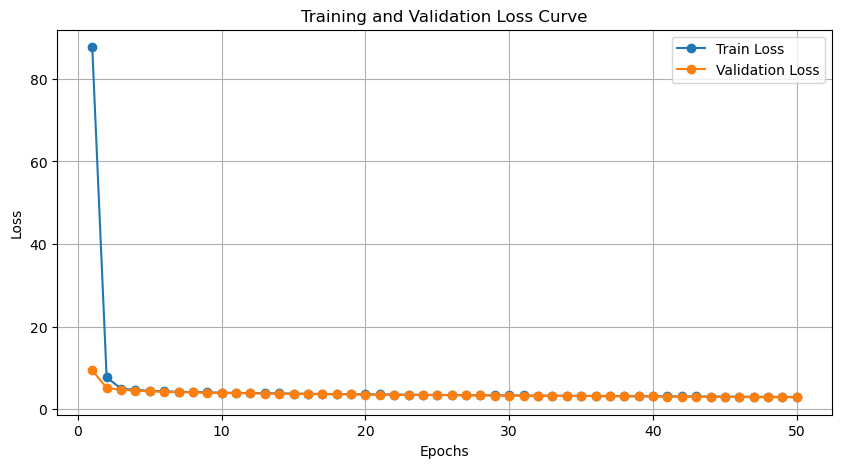

In [34]:
EPOCHS = 50 # 강화된 증강 데이터 학습을 위해 50 에폭 설정\n

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # 1. Train 
    total_train_loss = 0.0
    train_batches = len(train_dataloader)
    
    tqdm_bar = tqdm(total=train_batches, desc=f"Epoch {epoch+1} Train")

    # [GPT 변경 사항] 루프 변수명 x, y로 변경
    for batch, (x, y) in enumerate(train_dataloader):
    # for batch, (src, tgt) in enumerate(train_dataloader):
        step = epoch * train_batches + batch + 1
        lr = learning_rate(step)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        # [GPT 변경 사항] 루프 변수명 x, y로 변경
        loss = train_step(x, y, transformer, optimizer)    
        # loss = train_step(src, tgt, transformer, optimizer)
        total_train_loss += loss
        
        tqdm_bar.set_postfix({"Loss": f"{loss:.4f}"})
        tqdm_bar.update(1)
    tqdm_bar.close()
    
    avg_train_loss = total_train_loss / train_batches
    train_losses.append(avg_train_loss)
    
    # 2. Validation
    total_val_loss = 0.0
    val_batches = len(val_dataloader)
    
    # [GPT 변경 사항] 루프 변수명 x, y로 변경
    for x, y in val_dataloader:
        loss = val_step(x, y, transformer)
        total_val_loss += loss
    # for src, tgt in val_dataloader:
    #     loss = val_step(src, tgt, transformer)
    #     total_val_loss += loss
        
    avg_val_loss = total_val_loss / val_batches
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1} 완료 | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")

# 3. 러닝 커브 시각화
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 성능 평가

## 챗봇 답변 생성 함수 정의

In [35]:
# 튜닝 4: 빔 서치를 적용한 챗봇 답변 생성 함수 (버그 픽스 및 구조 개선)
def get_chat_response_beam(sentence, model, tokenizer, max_len=MAX_LEN, beam_size=3):
    model.eval()
    
    # 1. 전처리 및 형태소 분석
    clean_sentence = preprocess_sentence(sentence)
    tokens = mecab.morphs(clean_sentence)
    
    # [기존 코드 주석 처리]
    # 2. 인코딩 및 패딩
    # tokens_id = tokenizer.encode_as_ids(tokens)
    # padded = np.zeros((1, max_len), dtype=np.int64)
    # padded[0, :min(len(tokens_id), max_len)] = tokens_id[:min(len(tokens_id), max_len)]
    # src_in = torch.tensor(padded, dtype=torch.long, device=device)
    
    # [GPT 변경 사항] 입력 프롬프트 생성: <start> + 토큰 + <sep>
    tokens_id = [tokenizer.bos_id()] + tokenizer.encode_as_ids(tokens) + [tokenizer.sep_id()]

    # 3. 빔 서치를 위한 큐 초기화. (log_prob, [단어 인덱스들]) 형태
    # [기존 코드 주석 처리] 단순히 <start> 토큰 하나만 빔에 넣던 로직 제거
    # beams = [(0.0, [tokenizer.bos_id()])]
    
    # [새 코드] 위에서 만든 [질문 전체 프롬프트]를 빔의 초기값으로 넣습니다.
    beams = [(0.0, tokens_id)]

    with torch.no_grad():
        # [기존 코드 주석 처리] 
        # for _ in range(max_len):

        # [GPT 변경 사항] 이미 입력된 질문 길이만큼은 생성할 필요가 없으므로 빼줍니다.
        for _ in range(max_len - len(tokens_id)):
            new_beams = []
            for prob, seq in beams:
                # 이미 문장이 종료된 경우 그대로 유지시켜 보강
                if seq[-1] == tokenizer.eos_id():
                    new_beams.append((prob, seq))
                    continue
                
                # 모델 예측

                # 디코더 입력 텐서 생성 (기존 코드 유지)
                dec_in = torch.tensor(seq, dtype=torch.long, device=device).unsqueeze(0)

                # [기존 코드 주석 처리] src_in을 활용하던 3가지 마스크 생성 로직 제거
                # enc_mask, dec_enc_mask, dec_mask = generate_masks(src_in, dec_in)
                
                # [새 코드] 현재 시퀀스(dec_in)에 대한 단일 마스크만 생성
                dec_mask = generate_masks(dec_in)

                # [기존 코드 주석 처리] 모델 예측 로직 (인코더 입력 포함) 제거
                # predictions, _, _, _ = model(src_in, dec_in, enc_mask, dec_enc_mask, dec_mask)
                
                # [새 코드] GPT 모델 예측 로직
                predictions, _ = model(dec_in, dec_mask)

                # 마지막 토큰에 대한 로그 확률 계산
                logits = predictions[0, -1, :]  
                log_probs = torch.log_softmax(logits, dim=-1)
                
                # 상위 K(beam_size)개의 확률과 인덱스 추출
                topk_probs, topk_idx = torch.topk(log_probs, beam_size)
                
                for i in range(beam_size):
                    next_prob = prob + topk_probs[i].item()
                    next_seq = seq + [topk_idx[i].item()]
                    new_beams.append((next_prob, next_seq))
            
            # 누적 확률 내림차순 정렬 후 상위 beam_size 개만 업데이트
            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]
            
            # 모든 빔이 [EOS] 토큰을 마주쳐 종료되었으면 조기 중단
            if all(seq[-1] == tokenizer.eos_id() for _, seq in beams):
                break
                
    # 4. 가장 점수가 높은 첫 번째 후보 디코딩
    best_seq = beams[0][1]
    
    # [새 코드] 결과 문자열에서 어디서부터가 진짜 "답변"인지 찾습니다 (<sep> 다음부터)
    try:
        sep_idx = best_seq.index(tokenizer.sep_id())
        start_idx = sep_idx + 1 # 답변 시작 지점
    except ValueError:
        start_idx = len(tokens_id)

    try:
        eos_idx = best_seq.index(tokenizer.eos_id())
    except ValueError:
        eos_idx = len(best_seq)
        
    
    # [기존 코드 주석 처리] 무조건 인덱스 1번부터 자르던 로직 제거
    # final_ids = best_seq[1:eos_idx] # <start> 토큰 제외
    
    # [새 코드] <sep> 토큰 이후부터 <end> 토큰 이전까지만 잘라냅니다.
    final_ids = best_seq[start_idx:eos_idx]

    result = tokenizer.decode_ids(final_ids)
    return result

print("빔 서치 챗봇 함수 업데이트 완료!")

빔 서치 챗봇 함수 업데이트 완료!


## 챗봇 start

In [42]:
# [수정] 대화 내용을 저장할 빈 리스트 생성
chat_history = []

print("💬 GPT 챗봇과 대화를 시작합니다! (종료하려면 '종료' 또는 'q'를 입력하세요)\n" + "="*50)

while True:
    # 사용자로부터 텍스트 입력받기
    user_input = input("사용자: ")
    
    # 종료 조건 검사
    if user_input.strip() == '종료' or user_input.strip().lower() == 'q':
        print("GPT: 대화를 종료합니다. 고생하셨습니다!")
        break
        
    # 실수로 엔터만 쳤을 때(빈 입력) 방어
    if not user_input.strip():
        continue
        
    print(f"나: {user_input}")
    # 모델 답변 생성 (이전에 만든 빔 서치 함수 사용)
    response = get_chat_response_beam(user_input, transformer, tokenizer)
    print(f"GPT: {response}\n")

    # [수정] 사용자의 질문과 챗봇의 답변을 짝지어서 기록에 저장합니다.
    chat_history.append((user_input, response))

💬 GPT 챗봇과 대화를 시작합니다! (종료하려면 '종료' 또는 'q'를 입력하세요)
나: 안녕
GPT: 마음 이 복잡 하 겠 어요 .

나: 잘 잤어?
GPT: 잘 하 고 있 어요 .

나: 배고파?
GPT: 이별 은 언제나 힘들 겠 어요 .

나: 놀자
GPT: 좋 은 곳 으로 가 세요 .

GPT: 대화를 종료합니다. 고생하셨습니다!


## BLEU Score 정량 평가 0.0444

In [41]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                         candidate,
                         weights=weights,
                         smoothing_function=SmoothingFunction().method1)

# Validation 셋의 데이터 일부(예: 100개)를 사용해 평균 BLEU 측정
total_bleu = 0.0
sample_size = 100

print(f"Validation 데이터 {sample_size}개에 대한 BLEU Score 측정 중...")

for i in range(sample_size):
    # [기존 코드 주석 처리] 분리되어 있던 검증 데이터 사용 로직 제거
    # src_ids = enc_val[i].tolist()
    # tgt_ids = dec_val[i].tolist()
    # src_text = tokenizer.decode_ids(src_ids)
    # ref_text = tokenizer.decode_ids(tgt_ids)
    
    # [새 코드] 통합된 x_val에서 질문(Q)과 정답(A) 분리하기
    seq_ids = x_val[i].tolist()
    
    # 1. <sep> 토큰의 위치를 찾아 질문과 답변을 가릅니다.
    try:
        sep_idx = seq_ids.index(tokenizer.sep_id())
    except ValueError:
        continue # 만약 <sep>가 없는 비정상 데이터면 건너뜁니다.
        
    # 2. 질문 부분 추출 (<start> 바로 다음부터 <sep> 직전까지)
    q_ids = seq_ids[1:sep_idx]
    
    # 3. 정답 부분 추출 (<sep> 바로 다음부터 <eos> 직전까지)
    try:
        eos_idx = seq_ids.index(tokenizer.eos_id())
    except ValueError:
        eos_idx = len(seq_ids)
    a_ids = seq_ids[sep_idx+1:eos_idx]
    
    # 4. 정수로 된 토큰을 다시 텍스트로 변환
    src_text = tokenizer.decode_ids(q_ids)
    ref_text = tokenizer.decode_ids(a_ids)
    
    # (기존 코드 유지) 변환된 질문으로 모델에게 답변을 생성하게 함
    candidate_text = get_chat_response_beam(src_text, transformer, tokenizer)
    
    ref_tokens = ref_text.split()
    cand_tokens = candidate_text.split()
    
    # 빈 결과물이 나왔을 때 에러 방지
    if not cand_tokens:
        continue
    
    total_bleu += calculate_bleu(ref_tokens, cand_tokens)

avg_bleu = total_bleu / sample_size
print(f"\n평균 BLEU Score: {avg_bleu:.4f}")

Validation 데이터 100개에 대한 BLEU Score 측정 중...

평균 BLEU Score: 0.0444


## 어텐션 맵 시각화 및 테스트


📊 [1번째 대화 어텐션 맵]
Q: 안녕
A: 마음 이 복잡 하 겠 어요 .


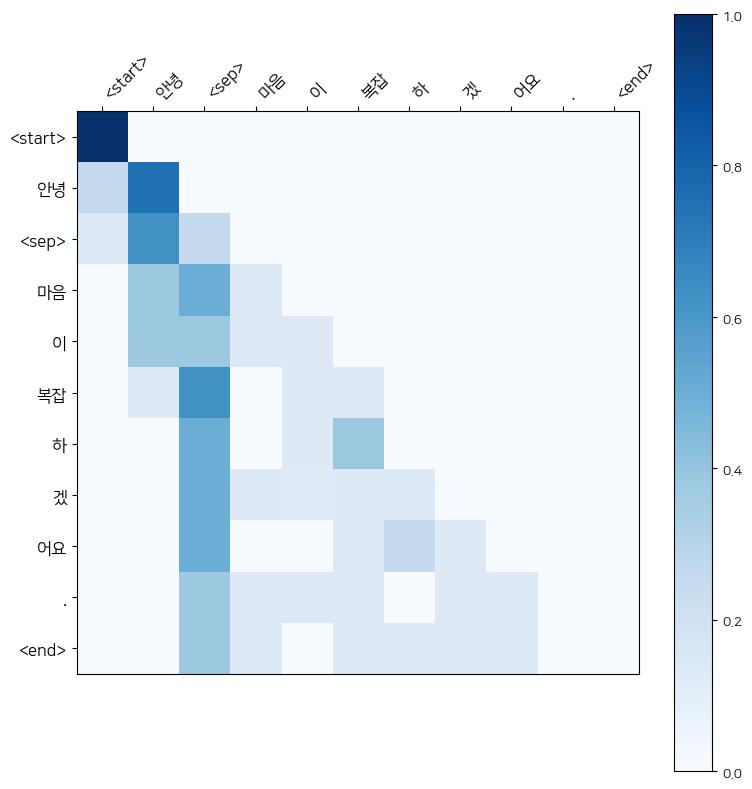


📊 [2번째 대화 어텐션 맵]
Q: 잘 잤어?
A: 잘 하 고 있 어요 .


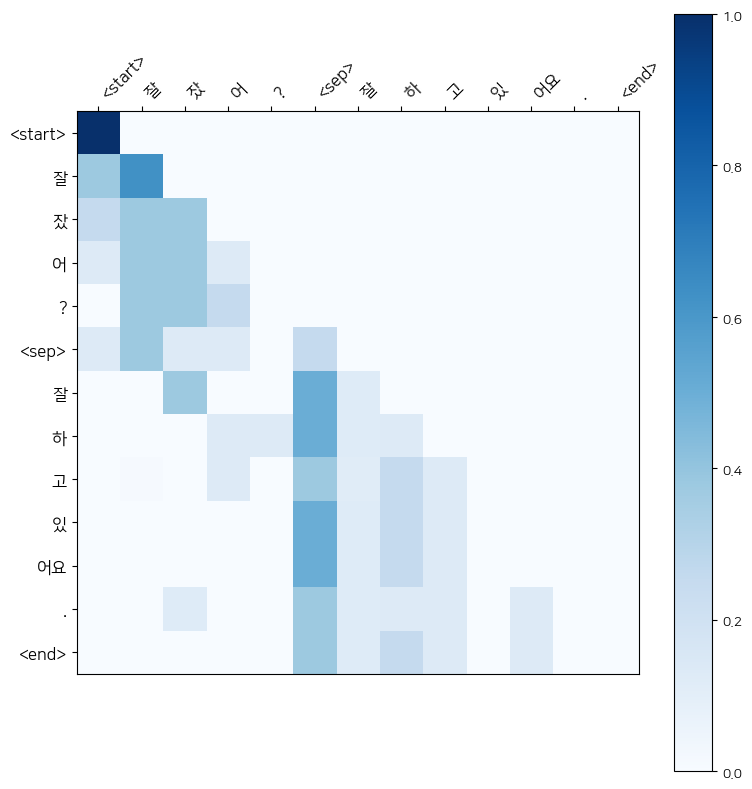


📊 [3번째 대화 어텐션 맵]
Q: 배고파?
A: 이별 은 언제나 힘들 겠 어요 .


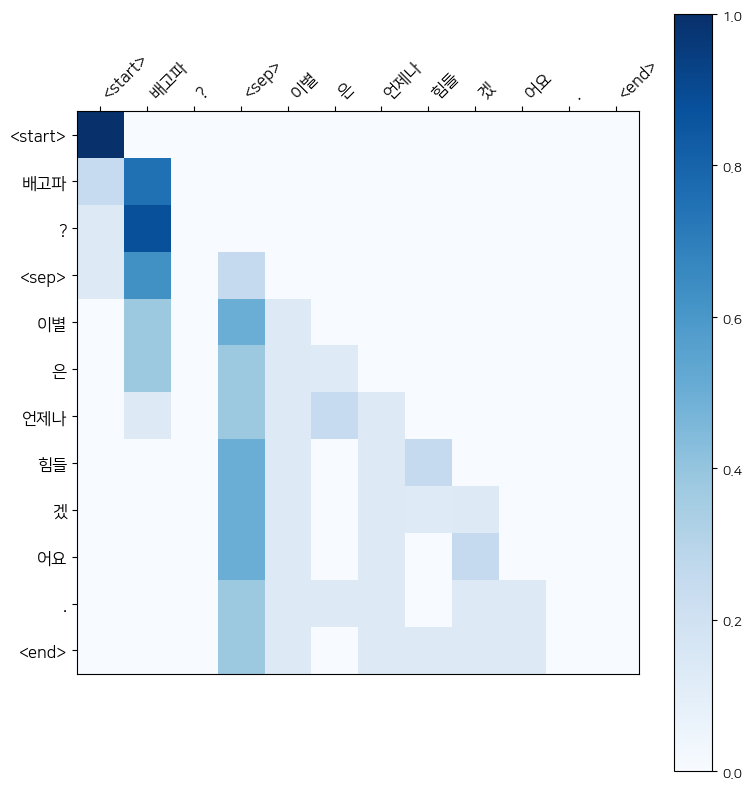


📊 [4번째 대화 어텐션 맵]
Q: 놀자
A: 좋 은 곳 으로 가 세요 .


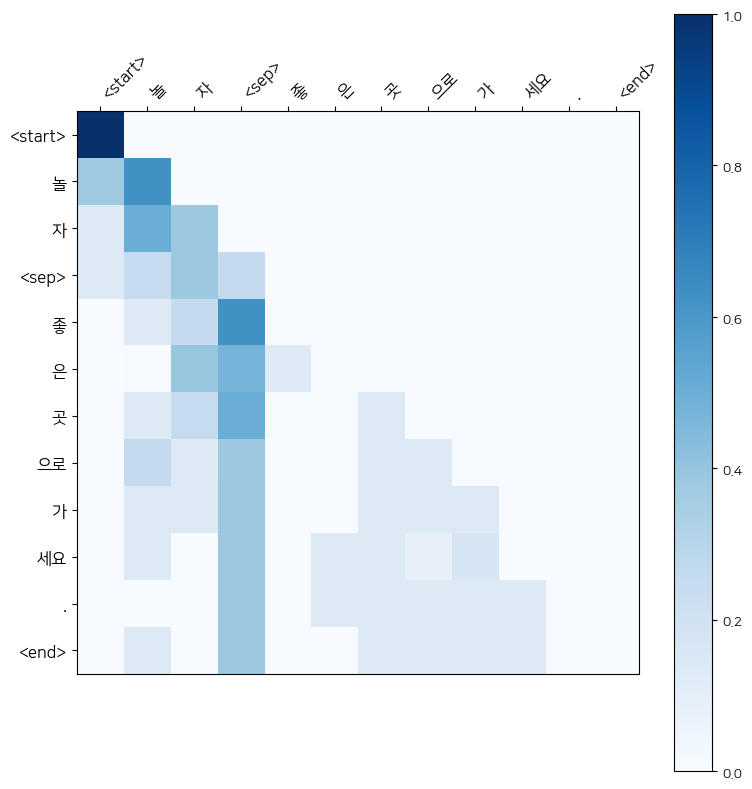

In [43]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch

# 한글 폰트 깨짐 방지 설정
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
nanum_fonts = [font for font in font_list if 'Nanum' in font]
if nanum_fonts:
    fm.fontManager.addfont(nanum_fonts[0])
    plt.rcParams['font.family'] = fm.FontProperties(fname=nanum_fonts[0]).get_name()
else:
    print("경고: 시스템 폰트에서 나눔고딕을 찾지 못했습니다.")
plt.rcParams['axes.unicode_minus'] = False

# 쌓인 대화 기록을 기반으로 어텐션 맵을 그리는 완전히 새로운 함수
def plot_attention_from_history(history, model, tokenizer, max_len=MAX_LEN):
    # 대화 기록이 없으면 안내 메시지 출력 후 종료
    if not history:
        print("저장된 대화 기록이 없습니다. 위 셀에서 챗봇과 먼저 대화를 나눠주세요!")
        return
        
    model.eval()
    
    # history에 저장된 (질문, 답변) 쌍을 순서대로 하나씩 꺼내옵니다.
    for i, (q, a) in enumerate(history):
        print(f"\n" + "="*50)
        print(f"📊 [{i+1}번째 대화 어텐션 맵]")
        print(f"Q: {q}")
        print(f"A: {a}")
        
        # 1. 사용자의 질문과 챗봇의 답변을 각각 형태소로 쪼갭니다.
        q_tokens = mecab.morphs(preprocess_sentence(q))
        a_tokens = mecab.morphs(preprocess_sentence(a))
        
        # 2. GPT 입력 형식(<start> + 질문 + <sep> + 답변 + <end>)으로 하나로 합칩니다.
        seq_ids = [tokenizer.bos_id()] + \
                  tokenizer.encode_as_ids(q_tokens) + \
                  [tokenizer.sep_id()] + \
                  tokenizer.encode_as_ids(a_tokens) + \
                  [tokenizer.eos_id()]
        
        # 길이가 최대 길이를 넘어가면 잘라줍니다.
        if len(seq_ids) > max_len:
            seq_ids = seq_ids[:max_len]
            
        # 3. 모델에 넣기 위해 텐서로 바꾸고(차원 추가) 마스크를 만듭니다.
        dec_in = torch.tensor(seq_ids, dtype=torch.long, device=device).unsqueeze(0)
        dec_mask = generate_masks(dec_in)
        
        # 4. 모델을 한 번 통과시켜서 셀프 어텐션 가중치(dec_attns)를 뽑아냅니다.
        with torch.no_grad():
            _, dec_attns = model(dec_in, dec_mask)
            
        # 5. 시각화할 데이터 정제: 마지막 레이어, 모든 헤드의 평균 어텐션 맵을 가져옵니다.
        # dec_attns[-1] shape: [1, num_heads, seq_len, seq_len] -> 평균 내면 [seq_len, seq_len]
        final_attn = dec_attns[-1][0].mean(dim=0).cpu().numpy()
        
        # 6. x축, y축에 표시할 단어 라벨을 준비합니다.
        labels = [tokenizer.index_to_word.get(idx, tokenizer.unk_token) for idx in seq_ids]
        
        # 7. 그래프 그리기
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(1, 1, 1)
        cax = ax.matshow(final_attn, cmap='Blues')
        
        # 축 설정 (단어 개수만큼 칸을 만듭니다)
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        
        # x축 글씨를 위쪽으로 올리고 45도 기울여서 겹치지 않게 합니다.
        ax.tick_params(axis="x", bottom=False, top=True, labelbottom=False, labeltop=True)
        ax.set_xticklabels(labels, fontdict={'fontsize': 12}, rotation=45, ha='left')
        ax.set_yticklabels(labels, fontdict={'fontsize': 12})
        
        fig.colorbar(cax)
        plt.tight_layout()
        plt.show()

# 챗봇 루프에서 저장된 대화 기록(chat_history)을 넣어 함수를 실행합니다.
plot_attention_from_history(chat_history, transformer, tokenizer)

# 추가 학습 (51~100회)

🚀 51회차부터 추가 학습을 시작합니다! (총 50회)


Epoch 51 Train:   0%|          | 0/691 [00:00<?, ?it/s]

Epoch 51 완료 | Train Loss: 2.9267 | Val Loss: 2.8600



Epoch 52 Train:   0%|          | 0/691 [00:00<?, ?it/s]

Epoch 52 완료 | Train Loss: 2.9065 | Val Loss: 2.8475



...

Epoch 98 완료 | Train Loss: 2.3508 | Val Loss: 2.2842



Epoch 99 Train:   0%|          | 0/691 [00:00<?, ?it/s]

Epoch 99 완료 | Train Loss: 2.3390 | Val Loss: 2.2767



Epoch 100 Train:   0%|          | 0/691 [00:00<?, ?it/s]

Epoch 100 완료 | Train Loss: 2.3321 | Val Loss: 2.2717



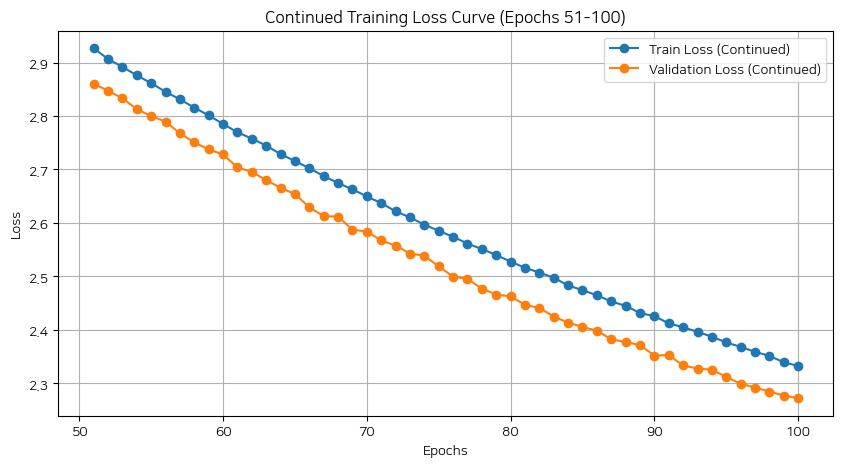

In [44]:
# ==========================================
# [추가 학습용 셀] 누적 에폭 자동 계산 연장 학습
# ==========================================
# 이전 훈련 셀에서 사용한 변수(EPOCHS)를 자동으로 받아옵니다.
# 첫 학습을 몇 번 했든, 이 셀을 실행하면 알아서 이어서 학습하고 스텝(step)도 맞춥니다.

ADD_EPOCHS = 50 # 이번에 추가로 더 돌릴 에폭 수만 지정하세요.
PREV_EPOCHS = EPOCHS # 💡 이전 셀에서 학습한 총 에폭 수를 자동으로 가져옵니다!

train_losses_continued = []
val_losses_continued = []

print(f"🚀 {PREV_EPOCHS + 1}회차부터 추가 학습을 시작합니다! (총 {ADD_EPOCHS}회)\n" + "="*50)

for epoch in range(ADD_EPOCHS):
    # 실제 모델이 인식할 누적 에폭 (예: 100 + 0 = 100 -> 101회차)
    current_epoch = PREV_EPOCHS + epoch 
    
    # 1. Train 
    total_train_loss = 0.0
    train_batches = len(train_dataloader)
    
    tqdm_bar = tqdm(total=train_batches, desc=f"Epoch {current_epoch + 1} Train")
    for batch, (x, y) in enumerate(train_dataloader):
        
        # 💡 스케줄러가 학습률을 초기화하지 않도록 누적 에폭 기반으로 스텝 계산
        step = current_epoch * train_batches + batch + 1
        
        lr = learning_rate(step)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
            
        loss = train_step(x, y, transformer, optimizer)
        total_train_loss += loss
        
        tqdm_bar.set_postfix({"Loss": f"{loss:.4f}", "LR": f"{lr:.6f}"})
        tqdm_bar.update(1)
    tqdm_bar.close()
    
    avg_train_loss = total_train_loss / train_batches
    train_losses_continued.append(avg_train_loss)
    
    # 2. Validation
    total_val_loss = 0.0
    val_batches = len(val_dataloader)
    
    for x, y in val_dataloader:
        loss = val_step(x, y, transformer)
        total_val_loss += loss
        
    avg_val_loss = total_val_loss / val_batches
    val_losses_continued.append(avg_val_loss)
    
    print(f"Epoch {current_epoch + 1} 완료 | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")

# 3. 추가 학습 러닝 커브 시각화
plt.figure(figsize=(10, 5))
epochs_range = range(PREV_EPOCHS + 1, PREV_EPOCHS + ADD_EPOCHS + 1)
plt.plot(epochs_range, train_losses_continued, label='Train Loss (Continued)', marker='o')
plt.plot(epochs_range, val_losses_continued, label='Validation Loss (Continued)', marker='o')
plt.title(f'Continued Training Loss Curve (Epochs {PREV_EPOCHS + 1}-{PREV_EPOCHS + ADD_EPOCHS})')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 💡 [핵심 팁] 다음 번 추가 학습을 위해 전체 누적 에폭 수를 갱신합니다.
# 이 셀을 한 번 더 실행하면, 자동으로 이어진 에폭부터 다시 시작합니다!
EPOCHS = PREV_EPOCHS + ADD_EPOCHS

# 성능 평가

## 챗봇 답변 생성 함수 정의

In [ ]:
# 튜닝 4: 빔 서치를 적용한 챗봇 답변 생성 함수 (버그 픽스 및 구조 개선)
def get_chat_response_beam(sentence, model, tokenizer, max_len=MAX_LEN, beam_size=3):
    model.eval()
    
    # 1. 전처리 및 형태소 분석
    clean_sentence = preprocess_sentence(sentence)
    tokens = mecab.morphs(clean_sentence)
    
    # [기존 코드 주석 처리]
    # 2. 인코딩 및 패딩
    # tokens_id = tokenizer.encode_as_ids(tokens)
    # padded = np.zeros((1, max_len), dtype=np.int64)
    # padded[0, :min(len(tokens_id), max_len)] = tokens_id[:min(len(tokens_id), max_len)]
    # src_in = torch.tensor(padded, dtype=torch.long, device=device)
    
    # [GPT 변경 사항] 입력 프롬프트 생성: <start> + 토큰 + <sep>
    tokens_id = [tokenizer.bos_id()] + tokenizer.encode_as_ids(tokens) + [tokenizer.sep_id()]

    # 3. 빔 서치를 위한 큐 초기화. (log_prob, [단어 인덱스들]) 형태
    # [기존 코드 주석 처리] 단순히 <start> 토큰 하나만 빔에 넣던 로직 제거
    # beams = [(0.0, [tokenizer.bos_id()])]
    
    # [새 코드] 위에서 만든 [질문 전체 프롬프트]를 빔의 초기값으로 넣습니다.
    beams = [(0.0, tokens_id)]

    with torch.no_grad():
        # [기존 코드 주석 처리] 
        # for _ in range(max_len):

        # [GPT 변경 사항] 이미 입력된 질문 길이만큼은 생성할 필요가 없으므로 빼줍니다.
        for _ in range(max_len - len(tokens_id)):
            new_beams = []
            for prob, seq in beams:
                # 이미 문장이 종료된 경우 그대로 유지시켜 보강
                if seq[-1] == tokenizer.eos_id():
                    new_beams.append((prob, seq))
                    continue
                
                # 모델 예측

                # 디코더 입력 텐서 생성 (기존 코드 유지)
                dec_in = torch.tensor(seq, dtype=torch.long, device=device).unsqueeze(0)

                # [기존 코드 주석 처리] src_in을 활용하던 3가지 마스크 생성 로직 제거
                # enc_mask, dec_enc_mask, dec_mask = generate_masks(src_in, dec_in)
                
                # [새 코드] 현재 시퀀스(dec_in)에 대한 단일 마스크만 생성
                dec_mask = generate_masks(dec_in)

                # [기존 코드 주석 처리] 모델 예측 로직 (인코더 입력 포함) 제거
                # predictions, _, _, _ = model(src_in, dec_in, enc_mask, dec_enc_mask, dec_mask)
                
                # [새 코드] GPT 모델 예측 로직
                predictions, _ = model(dec_in, dec_mask)

                # 마지막 토큰에 대한 로그 확률 계산
                logits = predictions[0, -1, :]  
                log_probs = torch.log_softmax(logits, dim=-1)
                
                # 상위 K(beam_size)개의 확률과 인덱스 추출
                topk_probs, topk_idx = torch.topk(log_probs, beam_size)
                
                for i in range(beam_size):
                    next_prob = prob + topk_probs[i].item()
                    next_seq = seq + [topk_idx[i].item()]
                    new_beams.append((next_prob, next_seq))
            
            # 누적 확률 내림차순 정렬 후 상위 beam_size 개만 업데이트
            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]
            
            # 모든 빔이 [EOS] 토큰을 마주쳐 종료되었으면 조기 중단
            if all(seq[-1] == tokenizer.eos_id() for _, seq in beams):
                break
                
    # 4. 가장 점수가 높은 첫 번째 후보 디코딩
    best_seq = beams[0][1]
    
    # [새 코드] 결과 문자열에서 어디서부터가 진짜 "답변"인지 찾습니다 (<sep> 다음부터)
    try:
        sep_idx = best_seq.index(tokenizer.sep_id())
        start_idx = sep_idx + 1 # 답변 시작 지점
    except ValueError:
        start_idx = len(tokens_id)

    try:
        eos_idx = best_seq.index(tokenizer.eos_id())
    except ValueError:
        eos_idx = len(best_seq)
        
    
    # [기존 코드 주석 처리] 무조건 인덱스 1번부터 자르던 로직 제거
    # final_ids = best_seq[1:eos_idx] # <start> 토큰 제외
    
    # [새 코드] <sep> 토큰 이후부터 <end> 토큰 이전까지만 잘라냅니다.
    final_ids = best_seq[start_idx:eos_idx]

    result = tokenizer.decode_ids(final_ids)
    return result

print("빔 서치 챗봇 함수 업데이트 완료!")

빔 서치 챗봇 함수 업데이트 완료!


## 챗봇 start

In [45]:
# [수정] 대화 내용을 저장할 빈 리스트 생성
chat_history = []

print("💬 GPT 챗봇과 대화를 시작합니다! (종료하려면 '종료' 또는 'q'를 입력하세요)\n" + "="*50)

while True:
    # 사용자로부터 텍스트 입력받기
    user_input = input("사용자: ")
    
    # 종료 조건 검사
    if user_input.strip() == '종료' or user_input.strip().lower() == 'q':
        print("GPT: 대화를 종료합니다. 고생하셨습니다!")
        break
        
    # 실수로 엔터만 쳤을 때(빈 입력) 방어
    if not user_input.strip():
        continue
        
    print(f"나: {user_input}")
    # 모델 답변 생성 (이전에 만든 빔 서치 함수 사용)
    response = get_chat_response_beam(user_input, transformer, tokenizer)
    print(f"GPT: {response}\n")

    # [수정] 사용자의 질문과 챗봇의 답변을 짝지어서 기록에 저장합니다.
    chat_history.append((user_input, response))

💬 GPT 챗봇과 대화를 시작합니다! (종료하려면 '종료' 또는 'q'를 입력하세요)
나: 안녕
GPT: 안녕 .

나: 잘잤어?
GPT: 당신 도 잘 지내 고 있 어요 .

나: 배고파
GPT: 그럴 때 가 있 어요 .

나: 놀자
GPT: 몸 상하 면 돼요 .

GPT: 대화를 종료합니다. 고생하셨습니다!


## BLEU Score 정량 평가

In [46]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                         candidate,
                         weights=weights,
                         smoothing_function=SmoothingFunction().method1)

# Validation 셋의 데이터 일부(예: 100개)를 사용해 평균 BLEU 측정
total_bleu = 0.0
sample_size = 100

print(f"Validation 데이터 {sample_size}개에 대한 BLEU Score 측정 중...")

for i in range(sample_size):
    # [기존 코드 주석 처리] 분리되어 있던 검증 데이터 사용 로직 제거
    # src_ids = enc_val[i].tolist()
    # tgt_ids = dec_val[i].tolist()
    # src_text = tokenizer.decode_ids(src_ids)
    # ref_text = tokenizer.decode_ids(tgt_ids)
    
    # [새 코드] 통합된 x_val에서 질문(Q)과 정답(A) 분리하기
    seq_ids = x_val[i].tolist()
    
    # 1. <sep> 토큰의 위치를 찾아 질문과 답변을 가릅니다.
    try:
        sep_idx = seq_ids.index(tokenizer.sep_id())
    except ValueError:
        continue # 만약 <sep>가 없는 비정상 데이터면 건너뜁니다.
        
    # 2. 질문 부분 추출 (<start> 바로 다음부터 <sep> 직전까지)
    q_ids = seq_ids[1:sep_idx]
    
    # 3. 정답 부분 추출 (<sep> 바로 다음부터 <eos> 직전까지)
    try:
        eos_idx = seq_ids.index(tokenizer.eos_id())
    except ValueError:
        eos_idx = len(seq_ids)
    a_ids = seq_ids[sep_idx+1:eos_idx]
    
    # 4. 정수로 된 토큰을 다시 텍스트로 변환
    src_text = tokenizer.decode_ids(q_ids)
    ref_text = tokenizer.decode_ids(a_ids)
    
    # (기존 코드 유지) 변환된 질문으로 모델에게 답변을 생성하게 함
    candidate_text = get_chat_response_beam(src_text, transformer, tokenizer)
    
    ref_tokens = ref_text.split()
    cand_tokens = candidate_text.split()
    
    # 빈 결과물이 나왔을 때 에러 방지
    if not cand_tokens:
        continue
    
    total_bleu += calculate_bleu(ref_tokens, cand_tokens)

avg_bleu = total_bleu / sample_size
print(f"\n평균 BLEU Score: {avg_bleu:.4f}")

Validation 데이터 100개에 대한 BLEU Score 측정 중...

평균 BLEU Score: 0.2146


## 어텐션 맵 시각화 및 테스트


📊 [1번째 대화 어텐션 맵]
Q: 안녕
A: 안녕 .


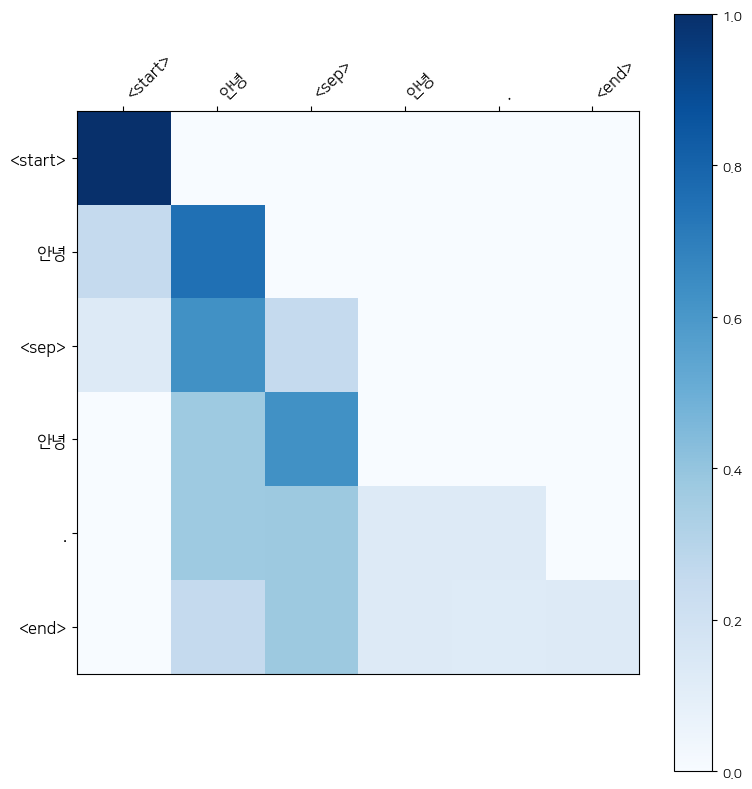


📊 [2번째 대화 어텐션 맵]
Q: 잘잤어?
A: 당신 도 잘 지내 고 있 어요 .


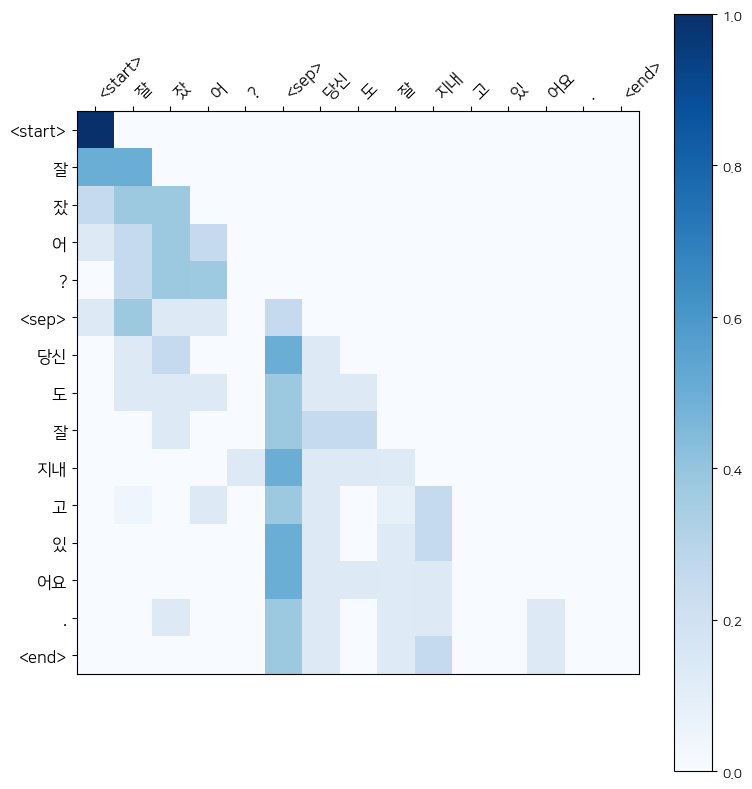


📊 [3번째 대화 어텐션 맵]
Q: 배고파
A: 그럴 때 가 있 어요 .


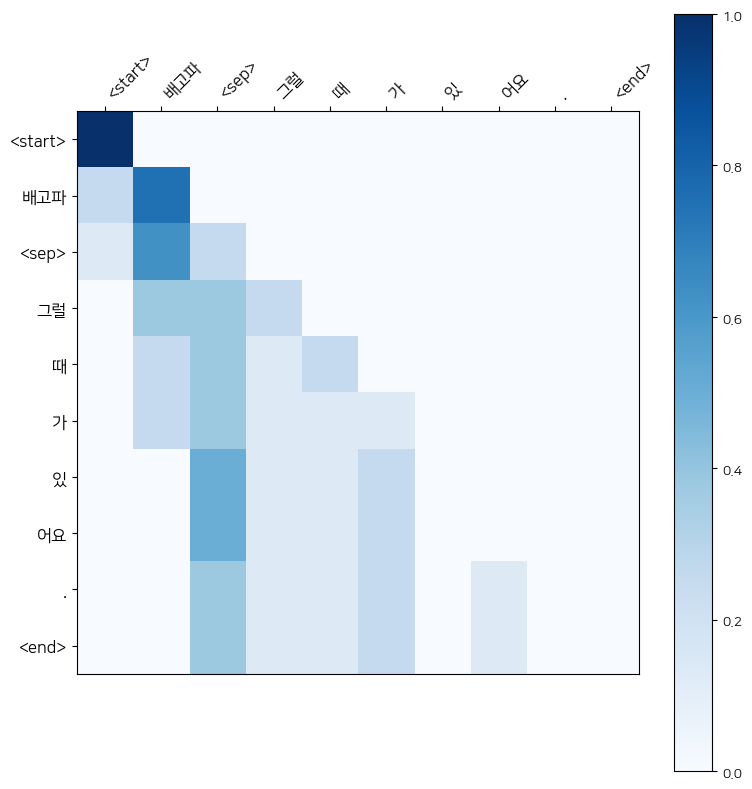


📊 [4번째 대화 어텐션 맵]
Q: 놀자
A: 몸 상하 면 돼요 .


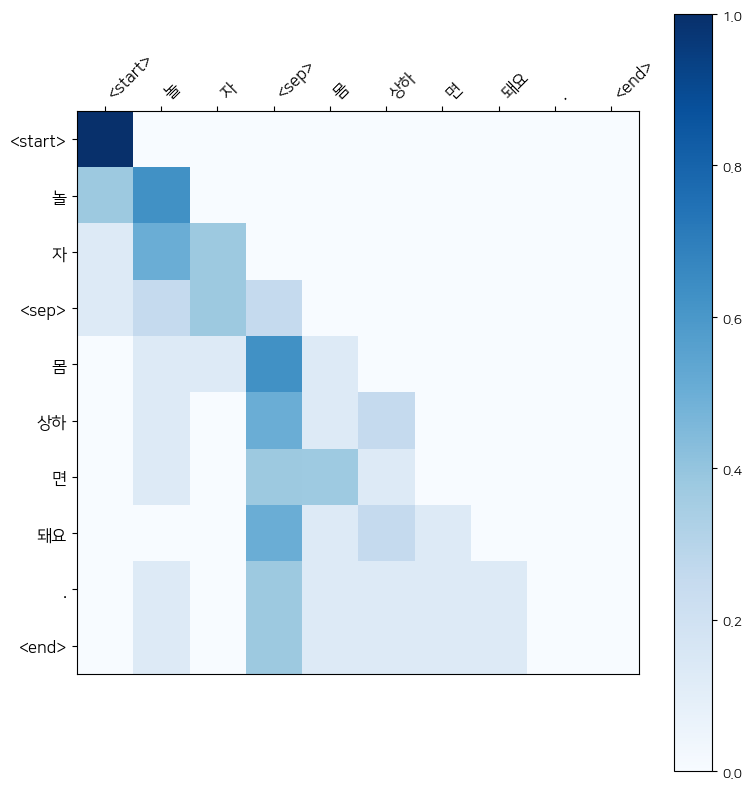

In [47]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch

# 한글 폰트 깨짐 방지 설정
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
nanum_fonts = [font for font in font_list if 'Nanum' in font]
if nanum_fonts:
    fm.fontManager.addfont(nanum_fonts[0])
    plt.rcParams['font.family'] = fm.FontProperties(fname=nanum_fonts[0]).get_name()
else:
    print("경고: 시스템 폰트에서 나눔고딕을 찾지 못했습니다.")
plt.rcParams['axes.unicode_minus'] = False

# 쌓인 대화 기록을 기반으로 어텐션 맵을 그리는 완전히 새로운 함수
def plot_attention_from_history(history, model, tokenizer, max_len=MAX_LEN):
    # 대화 기록이 없으면 안내 메시지 출력 후 종료
    if not history:
        print("저장된 대화 기록이 없습니다. 위 셀에서 챗봇과 먼저 대화를 나눠주세요!")
        return
        
    model.eval()
    
    # history에 저장된 (질문, 답변) 쌍을 순서대로 하나씩 꺼내옵니다.
    for i, (q, a) in enumerate(history):
        print(f"\n" + "="*50)
        print(f"📊 [{i+1}번째 대화 어텐션 맵]")
        print(f"Q: {q}")
        print(f"A: {a}")
        
        # 1. 사용자의 질문과 챗봇의 답변을 각각 형태소로 쪼갭니다.
        q_tokens = mecab.morphs(preprocess_sentence(q))
        a_tokens = mecab.morphs(preprocess_sentence(a))
        
        # 2. GPT 입력 형식(<start> + 질문 + <sep> + 답변 + <end>)으로 하나로 합칩니다.
        seq_ids = [tokenizer.bos_id()] + \
                  tokenizer.encode_as_ids(q_tokens) + \
                  [tokenizer.sep_id()] + \
                  tokenizer.encode_as_ids(a_tokens) + \
                  [tokenizer.eos_id()]
        
        # 길이가 최대 길이를 넘어가면 잘라줍니다.
        if len(seq_ids) > max_len:
            seq_ids = seq_ids[:max_len]
            
        # 3. 모델에 넣기 위해 텐서로 바꾸고(차원 추가) 마스크를 만듭니다.
        dec_in = torch.tensor(seq_ids, dtype=torch.long, device=device).unsqueeze(0)
        dec_mask = generate_masks(dec_in)
        
        # 4. 모델을 한 번 통과시켜서 셀프 어텐션 가중치(dec_attns)를 뽑아냅니다.
        with torch.no_grad():
            _, dec_attns = model(dec_in, dec_mask)
            
        # 5. 시각화할 데이터 정제: 마지막 레이어, 모든 헤드의 평균 어텐션 맵을 가져옵니다.
        # dec_attns[-1] shape: [1, num_heads, seq_len, seq_len] -> 평균 내면 [seq_len, seq_len]
        final_attn = dec_attns[-1][0].mean(dim=0).cpu().numpy()
        
        # 6. x축, y축에 표시할 단어 라벨을 준비합니다.
        labels = [tokenizer.index_to_word.get(idx, tokenizer.unk_token) for idx in seq_ids]
        
        # 7. 그래프 그리기
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(1, 1, 1)
        cax = ax.matshow(final_attn, cmap='Blues')
        
        # 축 설정 (단어 개수만큼 칸을 만듭니다)
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        
        # x축 글씨를 위쪽으로 올리고 45도 기울여서 겹치지 않게 합니다.
        ax.tick_params(axis="x", bottom=False, top=True, labelbottom=False, labeltop=True)
        ax.set_xticklabels(labels, fontdict={'fontsize': 12}, rotation=45, ha='left')
        ax.set_yticklabels(labels, fontdict={'fontsize': 12})
        
        fig.colorbar(cax)
        plt.tight_layout()
        plt.show()

# 챗봇 루프에서 저장된 대화 기록(chat_history)을 넣어 함수를 실행합니다.
plot_attention_from_history(chat_history, transformer, tokenizer)